In [1]:
import os
import time
import json
import pickle
import pandas as pd
import numpy as np

from datetime import datetime
from tqdm import tqdm
from dotenv import load_dotenv
from pathlib import Path

In [2]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
from sklearn.metrics.pairwise import cosine_similarity

from huggingface_hub import login
import torch
import torch.nn.functional as F
from transformers import AutoTokenizer, AutoModel
from vllm import LLM, SamplingParams

import mlflow
from databricks.sdk import WorkspaceClient

/opt/conda/lib/python3.11/site-packages/torch/utils/_pytree.py:185: FutureWarning: optree is installed but the version is too old to support PyTorch Dynamo in C++ pytree. C++ pytree support is disabled. Please consider upgrading optree using `python3 -m pip install --upgrade 'optree>=0.13.0'`.
  warnings.warn(
2025-12-06 12:17:39.524535: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:485] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2025-12-06 12:17:39.537968: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:8454] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2025-12-06 12:17:39.541911: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1452] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2025-12-06 12:17:39.552038: I tensorflow/core/platfor

INFO 12-06 12:17:41 [__init__.py:239] Automatically detected platform cuda.


In [3]:
import seaborn as sns
import matplotlib.pyplot as plt

Define path variables

In [4]:
model_id = "answerdotai/ModernBERT-large"

classification_type = "CLS_embedding"
model_name = "ModernBERT-large"
developer_initials = "JP"

In [5]:
current_dir = Path.cwd()
env_path = current_dir.parent.parent / "conf" / "local" / ".env"
results_path = current_dir.parent.parent / "results" / "transformer"

test_data_full_cleaned_path = current_dir.parent.parent / "data" /  "01_processed" / "pan21-authorship-verification-test-cleaned.jsonl"

Load environment variables
Get access to HuggingFace

In [6]:
load_dotenv(env_path)
huggingface_acess_token = os.getenv("huggingface_jp")

Connect to databricks for logging results

In [7]:
w = WorkspaceClient()   
print("Connected to:", w.config.host)

mlflow.set_tracking_uri("databricks")

Connected to: https://dbc-1ea3ad0e-f504.cloud.databricks.com


What are GPU are the experiments run on

In [8]:
!nvidia-smi

Sat Dec  6 12:17:44 2025       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.95.05              Driver Version: 580.95.05      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA A40                     Off |   00000000:A3:00.0 Off |                    0 |
|  0%   61C    P0            127W /  300W |    3449MiB /  46068MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [9]:
running_on_gpu = torch.cuda.is_available()

In [10]:
if running_on_gpu:
    gpu_name = torch.cuda.get_device_name(0)
    gpu_props = torch.cuda.get_device_properties(0)
    gpu_vram_gb = round(gpu_props.total_memory / (1024**3), 2)
else:
    gpu_name = "CPU"
    gpu_props = "N/A"
    gpu_vram_gb = 0

Empty the GPU from previous experiments

In [11]:
import gc
import torch
torch.cuda.empty_cache()
gc.collect()

199

In [12]:
os.environ["CUDA_VISIBLE_DEVICES"] = "0"

Classification threshold constant specification

In [36]:
thresholds = [x/1000 for x in range(900, 980)]

# Load dataset

Load testing data

In [14]:
test_data_file_size = os.path.getsize(test_data_full_cleaned_path)
test_data = []

with open(test_data_full_cleaned_path, 'r') as f:
    with tqdm(total=test_data_file_size, desc="Loading data", unit='B', unit_scale=True) as pbar:
        for line in f:
            test_data.append(json.loads(line))
            pbar.update(len(line.encode('utf-8')))

print(f"\nSuccessfully loaded {len(test_data)} items.")

Loading data: 100%|██████████| 826M/826M [00:03<00:00, 214MB/s] 


Successfully loaded 19999 items.


In [15]:
test_data_df = pd.DataFrame(test_data)
print(test_data_df.head(3))

                                     id  \
0  c28e8b03-c02a-5184-b58a-12dd28b8ca74   
1  b9326101-6352-56dd-9d1b-1f41466897b7   
2  e2ac4453-bf54-53f2-bf68-6caae6aacded   

                                                pair   same  
0  [talk because they hadnt been exposed to commu...   True  
1  [Zazuki nodded his head and got to his feet, k...   True  
2  [Oh we did lots of special things On Christmas...  False  


# Set up model

Log in to huggingface

In [16]:
login(huggingface_acess_token)

Load the model

In [17]:
tokenizer = AutoTokenizer.from_pretrained(model_id)
model = AutoModel.from_pretrained(model_id)

Set the processing to GPU

In [18]:
device = torch.device("cuda" if running_on_gpu else "cpu")
model = model.to(device)

In [19]:
model.eval()

ModernBertModel(
  (embeddings): ModernBertEmbeddings(
    (tok_embeddings): Embedding(50368, 1024, padding_idx=50283)
    (norm): LayerNorm((1024,), eps=1e-05, elementwise_affine=True)
    (drop): Dropout(p=0.0, inplace=False)
  )
  (layers): ModuleList(
    (0): ModernBertEncoderLayer(
      (attn_norm): Identity()
      (attn): ModernBertAttention(
        (Wqkv): Linear(in_features=1024, out_features=3072, bias=False)
        (rotary_emb): ModernBertRotaryEmbedding()
        (Wo): Linear(in_features=1024, out_features=1024, bias=False)
        (out_drop): Identity()
      )
      (mlp_norm): LayerNorm((1024,), eps=1e-05, elementwise_affine=True)
      (mlp): ModernBertMLP(
        (Wi): Linear(in_features=1024, out_features=5248, bias=False)
        (act): GELUActivation()
        (drop): Dropout(p=0.0, inplace=False)
        (Wo): Linear(in_features=2624, out_features=1024, bias=False)
      )
    )
    (1-27): 27 x ModernBertEncoderLayer(
      (attn_norm): LayerNorm((1024,), eps

# Evaluate model

Evaluate model function

In [20]:
def compute_similarities(test_data_df, model):
    start_time = time.time()
    verification_results = []
    
    def get_embedding(text: str):
        encoded = tokenizer(
            text,
            return_tensors="pt",
            truncation=True,
            padding= False,
            max_length=8192,
        ).to(device)
        
        with torch.no_grad():
            output = model(**encoded)
            cls_emb = output.last_hidden_state[:, 0, :]
            embedding = F.normalize(cls_emb, p=2, dim=1)
        return embedding.cpu()

    for i in tqdm(test_data_df.index, desc="Processing rows"):
        resulting_df_row = {}
        resulting_df_row['id']  = test_data_df.loc[i, 'id']
        resulting_df_row['actual_result'] = test_data_df.loc[i, 'same']
        text1 = test_data_df.loc[i, 'pair'][0]
        text2 = test_data_df.loc[i, 'pair'][1]
        
        text1_embedding = get_embedding(text1)
        text2_embedding = get_embedding(text2)

        cosine_similarity_score = cosine_similarity(text1_embedding, text2_embedding)


        sim_torch = F.cosine_similarity(text1_embedding, text2_embedding).item()        
        resulting_df_row['cosine_similarity'] = cosine_similarity_score
        verification_results.append(resulting_df_row)

    result_df = pd.DataFrame(verification_results)
    print("--- Execution Time: %s seconds ---" % round(time.time() - start_time, 2))

    return result_df

Compute similarities

In [21]:
result_df = compute_similarities(test_data_df, model)
result_df.head()

Processing rows: 100%|██████████| 19999/19999 [7:59:29<00:00,  1.44s/it]  

--- Execution Time: 28769.65 seconds ---


,id,actual_result,cosine_similarity
0,c28e8b03-c02a-5184-b58a-12dd28b8ca74,True,[[0.9132662]]
1,b9326101-6352-56dd-9d1b-1f41466897b7,True,[[0.98644364]]
2,e2ac4453-bf54-53f2-bf68-6caae6aacded,False,[[0.9682007]]
3,a5e9a289-0999-5764-b597-dc1bf8c21ede,True,[[0.96711814]]
4,cb4054b1-d422-58d6-a137-dcfc70100df6,True,[[0.97190493]]


Evaluation function

In [22]:
def evaluate_results(y_true, y_pred, average='binary'):
    accuracy = round(accuracy_score(y_true, y_pred)*100, 2)
    precision = round(precision_score(y_true, y_pred, average=average)*100, 2)
    recall = round(recall_score(y_true, y_pred, average=average)*100, 2)
    f1 = round(f1_score(y_true, y_pred, average=average)*100, 2)
    return accuracy, precision, recall, f1

Optimal threshold search

In [23]:
def evaluate_classification_thresholds(result_df, classification_thresholds):
    results = []
    y_embeddings = result_df['cosine_similarity']
    y_true = result_df['actual_result']
    for threshold in thresholds:
        y_pred = (result_df["cosine_similarity"] >= threshold).astype(int)
        accuracy, precision, recall, f1 = evaluate_results(y_true, y_pred)
        results.append({
            "threshold": threshold,
            "accuracy" : accuracy,
            "precision" : precision,
            "recall" : recall,
            "f1" : f1
        })
    return pd.DataFrame(results)

Evaluate thresholds

In [45]:
threshold_results_df = evaluate_classification_thresholds(result_df, thresholds)

Create histogram of F1 score for different thresholds

In [46]:
def plot_f1_vs_threshold(results_df):
    plt.figure(figsize=(9, 5))
    plt.plot(results_df["threshold"], results_df["f1"], linewidth=2)
    plt.xlabel("Threshold")
    plt.ylabel("F1 Score")
    plt.title("F1 Score vs Classification Threshold")
    plt.grid(True)
    plt.tight_layout()
    return plt.gcf()

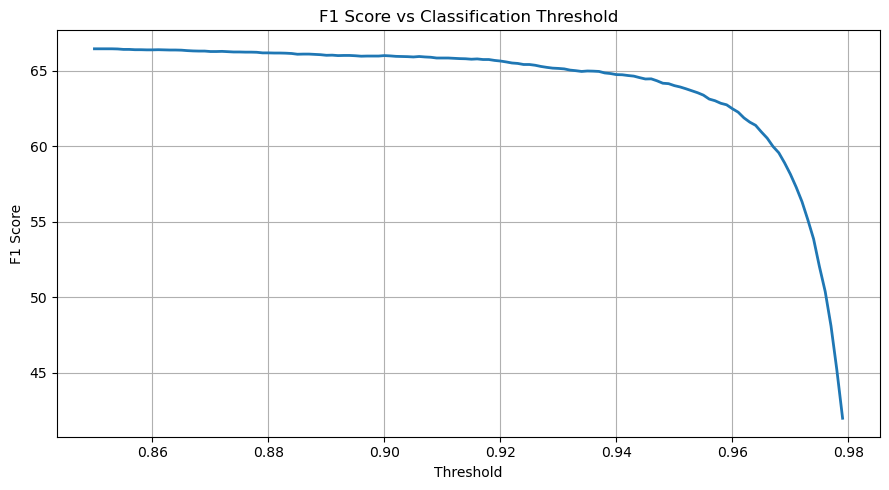

In [47]:
f1_threshold_histogram_fig = plot_f1_vs_threshold(threshold_results_df)
f1_threshold_histogram_fig.show()

Print top 5 results

In [48]:
sorted_threshold_results_df = threshold_results_df.sort_values("f1", ascending=False)
top5_results = sorted_threshold_results_df.head(5)

print("Top 5 thresholds by F1:")
print(top5_results)

Top 5 thresholds by F1:
   threshold  accuracy  precision  recall     f1
0      0.850     50.57      50.30   97.97  66.47
3      0.853     50.64      50.33   97.86  66.47
1      0.851     50.59      50.30   97.94  66.47
2      0.852     50.62      50.32   97.90  66.47
4      0.854     50.63      50.32   97.81  66.46


Pick the best result and compute y_pred

In [49]:
top_threshold = top5_results.iloc[0]["threshold"]

y_true = result_df['actual_result']
y_pred = (result_df["cosine_similarity"] >= top_threshold).astype(int).values

best_accuracy, best_precision, best_recall, best_f1 = evaluate_results(y_true, y_pred)

Create the confusion matrix

Text(0.5, 1.0, 'Confusion Matrix: answerdotai/ModernBERT-large')

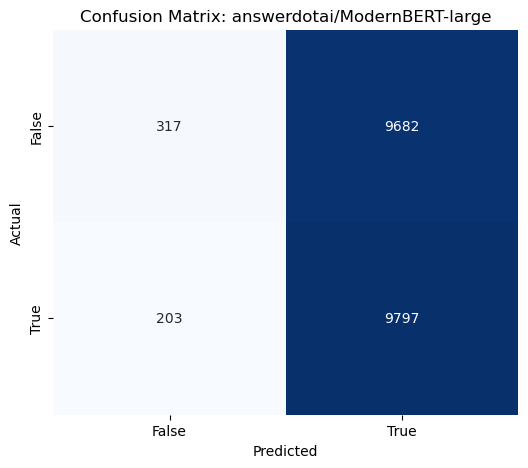

In [50]:
labels = [False, True] 
cm = confusion_matrix(y_true, y_pred, labels=labels)

cm_fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(cm, annot=True, 
            fmt='d', 
            cmap='Blues',
            xticklabels=labels, 
            yticklabels=labels, 
            ax=ax,
            cbar=False)
ax.set_xlabel('Predicted')
ax.set_ylabel('Actual')
ax.set_title(f'Confusion Matrix: {model_id}')

Log model information + metrics + results table + confusion matrix

In [51]:
date_str = datetime.now().strftime("%Y%m%d_%H%M")
mlflow.set_experiment("/Users/jiripokorny455@gmail.com/JP_authorship_verification_dt")
with mlflow.start_run(run_name=f"{developer_initials}_{model_name}_results_{classification_type}"):
    mlflow.log_param("gpu_name", gpu_name)
    mlflow.log_param("gpu_vram_gb", gpu_vram_gb)
    
    mlflow.log_param("model_id ", model_id )
    mlflow.log_param("classification_type", classification_type)
    
    mlflow.log_param("classification_thresholds", thresholds)

    mlflow.log_table(data=result_df, artifact_file="embedding_similarity_results.json")
    mlflow.log_table(data=threshold_results_df, artifact_file="results_for_different_thresholds.json")
    
    mlflow.log_metric("top_result_accuracy", best_accuracy)
    mlflow.log_metric("top_precision", best_precision)
    mlflow.log_metric("top_recall", best_recall)
    mlflow.log_metric("top_f1", best_f1)

    mlflow.log_figure(f1_threshold_histogram_fig, "f1_results_threshold_histogram.png")
    mlflow.log_figure(cm_fig, "confusion_matrix.png")

🏃 View run JP_ModernBERT-large_results_CLS embedding similarity without fine-tuning at: https://dbc-1ea3ad0e-f504.cloud.databricks.com/ml/experiments/134079680834040/runs/bdf2af78f1a7411e983ef9d73356a688
🧪 View experiment at: https://dbc-1ea3ad0e-f504.cloud.databricks.com/ml/experiments/134079680834040
